In [26]:
import pandas as pd
import seaborn as sns
import altair as alt
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

df = pd.read_csv('../data/universal_top_spotify_songs.csv')
df = df.drop(columns=['spotify_id', 'daily_rank', 'daily_movement', 'weekly_movement', 'snapshot_date', 'name', 'album_release_date', 'album_name'])

countries = ['GB', 'DE', 'FR', 'ES', 'IT', 'NL', 'SE', 'PL', 'BE', 'PT']

df = df[df['country'].isin(countries)]
df = df.groupby('country').head(500)


df

In [ ]:
df.to_csv('../data/top_spotify_songs_EU_cleaned.csv', index=False) #remove index

In [ ]:
##Continued Cleaning

df = pd.read_csv('../data/top_spotify_songs_EU_cleaned.csv')
df.head(5)

In [5]:
df['duration_s'] = df['duration_ms'] / 1000
df = df.drop(columns=['duration_ms'])

In [6]:
df['artist_count'] = df['artists'].str.split(',').str.len()

In [7]:
print(max(df['artist_count']))
df['artists'] = df['artists'].str.lower()
df['artists_list'] = df['artists'].str.split(', ')

df_exploded = df.explode('artists_list')


7


In [8]:
df.head(5)
df

,artists,country,popularity,is_explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_s,artist_count,artists_list
0,"tjuvjakt, fanny avonne",SE,76,False,0.735,0.6530,3,-6.261,1,0.0533,0.3600,0.000000,0.0791,0.620,116.002,4,190.344,2,"[tjuvjakt, fanny avonne]"
1,ida-lova,SE,77,False,0.404,0.6830,1,-6.969,1,0.0594,0.3020,0.000000,0.3180,0.661,162.091,4,187.076,1,[ida-lova]
2,lov1,SE,64,False,0.695,0.6760,8,-6.859,1,0.0384,0.1010,0.000000,0.0929,0.431,121.962,4,208.201,1,[lov1]
3,kaj,SE,75,False,0.757,0.8890,9,-4.729,0,0.0788,0.0754,0.000023,0.0397,0.754,106.037,4,166.880,1,[kaj]
4,"humlan djojj, josefine götestam",SE,76,False,0.684,0.0326,0,-17.898,1,0.0583,0.9730,0.000002,0.1080,0.440,66.685,5,140.046,2,"[humlan djojj, josefine götestam]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,chappell roan,GB,48,False,0.742,0.7570,6,-4.981,1,0.0421,0.0187,0.000000,0.3050,0.957,139.982,4,184.841,1,[chappell roan]
4996,central cee,GB,36,True,0.750,0.7370,11,-4.245,0,0.3000,0.4450,0.000000,0.0772,0.962,142.402,4,198.400,1,[central cee]
4997,myles smith,GB,75,False,0.762,0.7830,5,-5.206,0,0.0387,0.3290,0.000000,0.0536,0.840,115.091,4,176.000,1,[myles smith]
4998,"pawsa, the adventures of stevie v",GB,81,False,0.783,0.4730,0,-6.493,1,0.1670,0.0693,0.000034,0.1490,0.539,131.890,4,221.448,2,"[pawsa, the adventures of stevie v]"


In [ ]:
df.to_csv('../data/fully_cleaned_top_spotify_songs_EU.csv', index=False) #cleaned new df

In [11]:
country_avg = df.groupby("country").mean(numeric_only=True)

country_avg

,popularity,is_explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_s,artist_count
country,,,,,,,,,,,,,,,,
BE,82.828,0.454,0.702728,0.653092,5.272,-6.716694,0.378,0.112215,0.230072,0.011835,0.144861,0.547368,126.805822,3.870,191.596562,1.418
DE,79.472,0.388,0.689004,0.725318,5.492,-6.334202,0.468,0.132280,0.137902,0.020435,0.189211,0.529682,131.578170,3.924,172.123630,1.446
ES,81.556,0.454,0.673168,0.640796,6.026,-8.554018,0.420,0.100927,0.339315,0.079220,0.154196,0.515844,114.169828,3.980,192.650398,1.792
FR,77.050,0.672,0.756512,0.642770,5.480,-7.152706,0.244,0.158255,0.254103,0.005525,0.121831,0.590458,123.718228,3.880,185.842176,1.326
GB,74.384,0.426,0.656066,0.665534,5.730,-5.962992,0.654,0.079561,0.202196,0.003929,0.172261,0.534233,121.443078,3.898,203.390790,1.278
IT,73.084,0.338,0.637174,0.661714,5.424,-6.601326,0.638,0.096896,0.238157,0.024310,0.175710,0.498106,127.229036,3.938,195.451376,1.652
NL,76.930,0.182,0.687918,0.705958,5.498,-6.013050,0.548,0.072931,0.181912,0.004420,0.155653,0.607634,125.978194,3.890,177.663306,1.656
PL,72.206,0.332,0.665030,0.673910,5.302,-7.452580,0.472,0.123111,0.220719,0.010388,0.176085,0.495431,126.573884,3.952,184.450790,2.150
PT,78.774,0.272,0.686368,0.627768,6.310,-7.416806,0.452,0.144456,0.290494,0.049132,0.163956,0.520996,122.386460,3.922,186.695486,2.126


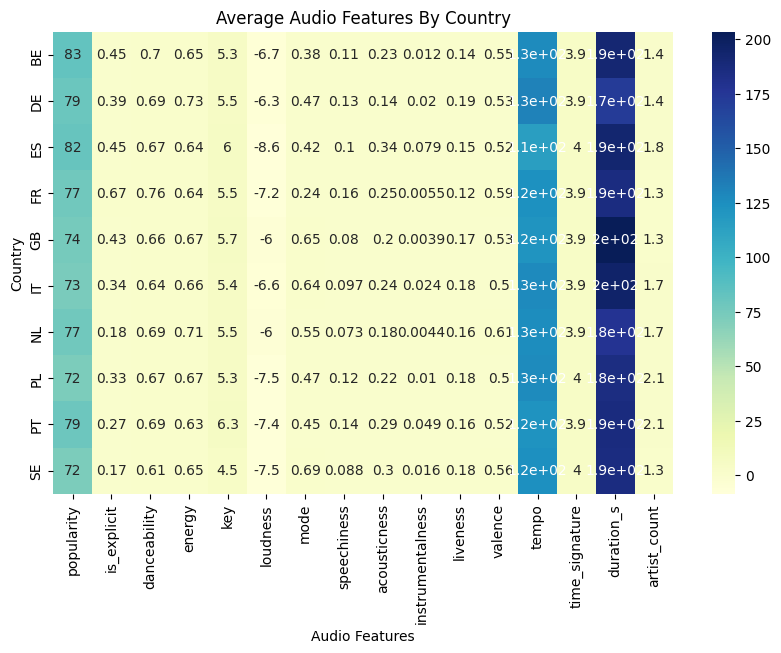

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(country_avg, annot=True, cmap="YlGnBu")
plt.title("Average Audio Features By Country")
plt.xlabel("Audio Features")
plt.ylabel("Country")
plt.show()

In [40]:
chart = alt.Chart(df).mark_circle(size=50, opacity=0.7).encode(
    x=alt.X('energy', title='Energy'),
    y=alt.Y('valence', title='Valence'),
    color=alt.Color('country', legend=alt.Legend(title='Country')),
    tooltip=['country', 'artists_list', 'energy', 'valence']).properties(
    title='Energy vs. Valence',
    width=500,
    height=400).interactive()
chart


alt.Chart(...)